# Let's play with some data in Google NODD

## Let's plot some stream data

* Daily stream flow data https://noaa-nwfsc.github.io/Streamflow-Means-NWM/

First we will plot flow lines from the Willamette Valley in Oregon.

<Axes: >

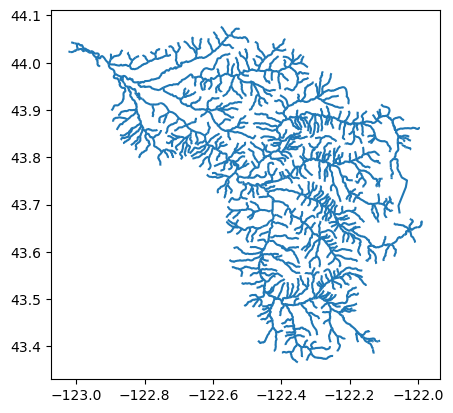

In [1]:
import geopandas as gpd
data_path = "gcs://nmfs_odp_nwfsc/CB/nwm_daily_means/wr1718/flowline/WR_17_Flowline.parquet"
gdf = gpd.read_parquet(data_path, storage_options={"token": "anon"})
gdf["HUC8"] = gdf["REACHCODE"].astype(str).str.slice(0, 8)
gdf = gdf[gdf["HUC8"] == "17090001"]  # optional filter
gdf.plot()

You did the following:

* Accessed a very large dataset of stream lines
* Loaded on the needed data into memory
* Made a plot

You did not have to load anything onto your computer. It all happened in the cloud.

### Let's do something bigger

We will plot lines from a big HUC (multiple watersheds) east of San Francisco.

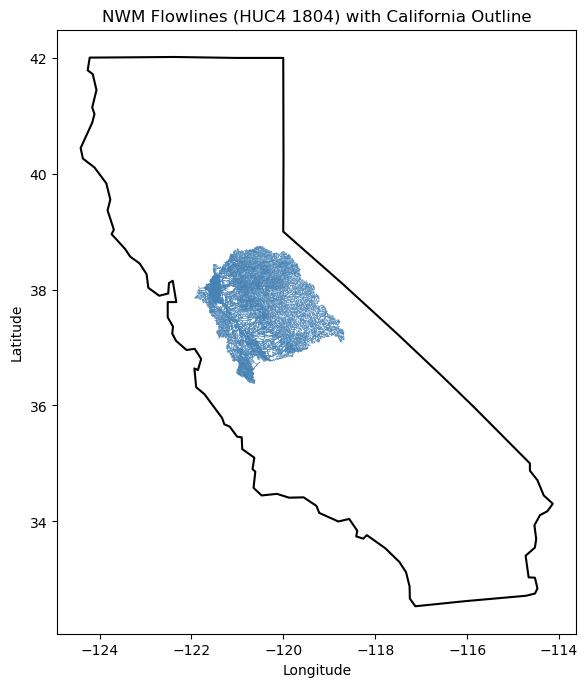

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# --- flowlines ---
data_path = (
    "gcs://nmfs_odp_nwfsc/CB/nwm_daily_means/wr1718/"
    "flowline/WR_18_Flowline.parquet"
)
gdf = gpd.read_parquet(data_path, storage_options={"token": "anon"})
gdf = gdf[gdf["HUC4"] == "1804"]

# --- US states (public Natural Earth-style dataset) ---
states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

california = states[states["name"] == "California"]

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 8))

california.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
    zorder=1,
)

gdf.plot(
    ax=ax,
    color="steelblue",
    linewidth=0.5,
    zorder=2,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("NWM Flowlines (HUC4 1804) with California Outline")

plt.tight_layout()
plt.show()

## Let's work with a really big dataset

This is a multi-terrabyte data set of daily global peak depth of chlorophyll in the ocean. This is from some of my recent work using a new hyperspectral ocean color dataset. This work involved lots of cloud data and cloud computing.

* Accessing NASA data in the cloud
* Running models on 20 different virtual machines at once
* Outputting the result in cloud-native Zarr format for fast access
* Putting the data into Google NODD cloud buckets.

### Open the dataset

In [5]:
import xarray as xr
zarr_path = "gcs://nmfs_odp_nwfsc/CB/fish-pace-datasets/chla-z/zarr"
ds = xr.open_zarr(zarr_path, consolidated=False, storage_options={"token": "anon"})
ds

GroupNotFoundError: group not found at path ''

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

zarr_path = "gcs://nmfs_odp_nwfsc/CB/fish-pace-datasets/chla-z/zarr"
ds = xr.open_zarr(zarr_path, consolidated=False, storage_options={"token": "anon"})

# --- small ROI for time series ---
lat_small = (17, 15)
lon_small = (-55, -53)

# rectangle bounds (ensure min/max ordering)
lat_min, lat_max = sorted(lat_small)
lon_min, lon_max = sorted(lon_small)

# A "bigger area" map slice to plot (adjust padding as you like)
pad_lat = 12
pad_lon = 20
map_da = ds["CHLA_peak_depth"].isel(time=0).sel(
    lat=slice(lat_max + pad_lat, lat_min - pad_lat),
    lon=slice(lon_min - pad_lon, lon_max + pad_lon),
)
map_da = ds["CHLA_peak_depth"].isel(time=0).coarsen(lat=4, lon=4, boundary="trim").mean()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(
    projection=ccrs.Orthographic(
        central_longitude=(lon_min + lon_max) / 2,
        central_latitude=(lat_min + lat_max) / 2,
    )
)

ax.set_global()
ax.add_feature(cfeature.LAND, linewidth=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

# plot data (lon/lat grid -> PlateCarree)
map_da.plot(ax=ax, transform=ccrs.PlateCarree(), robust=True, add_colorbar=True)

# ROI box in red
xs = [lon_min, lon_max, lon_max, lon_min, lon_min]
ys = [lat_min, lat_min, lat_max, lat_max, lat_min]
ax.plot(xs, ys, transform=ccrs.PlateCarree(), linewidth=2, color="red")

ax.set_title("CHLA_peak_depth (time=0) with ROI box")
plt.tight_layout()
plt.show()

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

zarr_path = "gcs://nmfs_odp_nwfsc/CB/fish-pace-datasets/chla-z/zarr"
ds = xr.open_zarr(zarr_path, consolidated=False, storage_options={"token": "anon"})

da = ds["CHLA_peak_depth"]

# small region of interest
roi = da.sel(lat=slice(17, 15), lon=slice(-55, -53))

# monthly mean within ROI:
# 1) mean over space (lat/lon) for each timestep
# 2) resample to month starts and mean over time within each month
ts = roi.mean(("lat", "lon")).resample(time="MS").mean("time").compute()

# Plot
ts.plot(marker="o")
plt.title("Monthly mean CHLA_peak_depth in ROI (17–15N, 55–53W)")
plt.ylabel("CHLA_peak_depth")
plt.show()